In [ ]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('../..')
import plot_settings
import importlib
#import multi_exp_log
import Param_symbol

from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)

import_reload()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


# Importing data

In [2]:
DT = 1
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [3]:
def prepare_data(data, index = 0, test = False):
    if test:
        i = index + int(0.8*len(data['trajectory'].unique()))
    else:
        i = index

    trajs = data[data['trajectory'] == i].reset_index(drop=True)

    return trajs

In [4]:


def read_data(file_name):
    df = pd.read_csv(
        f"data/{file_name}.txt",
        sep=',',
        comment="%"
    )
    # cols = u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
    #df.columns = ['u_par','C','t','V','I','F','u','Ue','eta','trajectory','dV','dF','soc']
    # Sort by time within each batch
    return df


path = f'ecm_elements_netR0_netC1_56.9030min_1b_32h_100eps'

data = read_data(path)
data['R1'] = data['R1'] * 1000
data['C1'] = data['C1'] / 1000
data['R0'] = data['R0'] * 1000
display(data.head())


,trajectory,soc,R1,C1,R0,C,u_per
0,0,0.999861,0.643857,5.710732,18.216460,0.5,28.2
1,0,0.999722,0.644119,5.709751,18.217484,0.5,28.2
2,0,0.999583,0.644381,5.708770,18.218512,0.5,28.2
3,0,0.999444,0.644643,5.707789,18.219536,0.5,28.2
4,0,0.999306,0.644905,5.706808,18.220555,0.5,28.2


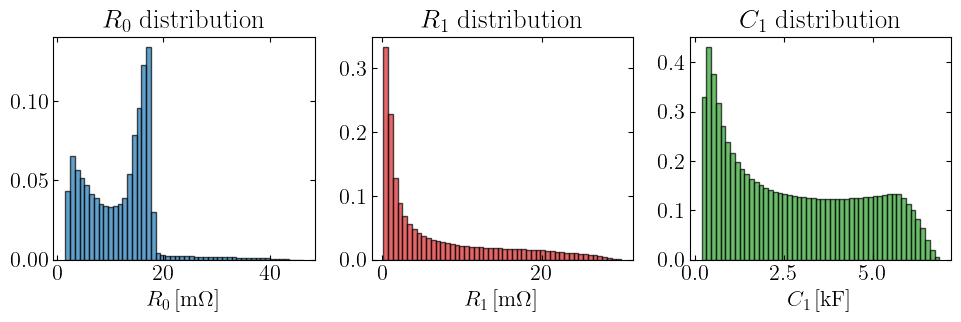

In [5]:
f,ax = plt.subplots(1,3, figsize=(10,3.5))
ax[0].hist(data['R0'], bins=50, color=colors[0], alpha=0.7,edgecolor='black', density=True)
ax[0].set_title(r'$R_0$ distribution')
ax[0].set_xlabel(r'$R_0\,$[m$\Omega$]')

ax[1].hist(data['R1'], bins=50, color=colors[1], alpha=0.7,edgecolor='black', density=True)
ax[1].set_title(r'$R_1$ distribution')
ax[1].set_xlabel(r'$R_1\,$[m$\Omega$]')

ax[2].hist( data['C1'], bins=50, color=colors[2], alpha=0.7,edgecolor='black', density=True)
ax[2].set_title(r'$C_1$ distribution')
ax[2].set_xlabel(r'$C_1\,$[kF]')
plt.tight_layout()


## The sampled terrain

In [6]:
# u_C_pairs = data.loc[data['t'] == 0, ['u_par', 'C','trajectory']]
# plt.xlabel('C-rate [Ah]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.plot(u_C_pairs['C'], u_C_pairs['u_par'], 'o')

In [7]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 5e4:
            break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values
    Y_R1 = d_frame['R1'].values
    Y_C1 = d_frame['C1'].values
    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds], Y_R0[inds], Y_R1[inds], Y_C1[inds]

In [8]:
split_train = int(data['trajectory'].max() * 0.8)
data_train = data[data['trajectory'] <= split_train]
data_test = data[data['trajectory'] > split_train]
trajs_train = prepare_data(data_train)
trajs_test = prepare_data(data_test)

X_train, YR0_train, YR1_train, YC_train = get_XY(data_train)

X_test, YR0_test,YR1_test, YC_test = get_XY(data_test)


# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


Using every 8th data point for symbolic regression, total points: 47998
Using every 1th data point for symbolic regression, total points: 31577


In [51]:
def print_models(df_model):
    for i in range(len(df_model)):
        print(f"Model {i}: Complexity={df_model['complexity'][i]}, Loss={df_model['loss'][i]}")
        print(f"Equation: {df_model['equation'][i]}\n")

def print_best_model(model, model_index = None):
    best = model.get_best()
    display(Math(f'\\LARGE {model.latex(model_index)}'))
    display(Math('\LARGE $x_0 = \mathrm{{c}}$-rate$'))
    display(Math('\LARGE $x_1 = \Delta u / L_{{tot}}$'))
    display(Math('\LARGE $x_2 = \mathrm{SOC}$'))
    print(f'Best model in symbolic form: {model.sympy()}\nLoss: {best["loss"]}\nBest model complexity: {best["complexity"]}')

<>:9: SyntaxWarning: invalid escape sequence '\L'
<>:10: SyntaxWarning: invalid escape sequence '\L'
<>:11: SyntaxWarning: invalid escape sequence '\L'
<>:9: SyntaxWarning: invalid escape sequence '\L'
<>:10: SyntaxWarning: invalid escape sequence '\L'
<>:11: SyntaxWarning: invalid escape sequence '\L'
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_6993/61501257.py:9: SyntaxWarning: invalid escape sequence '\L'
  display(Math('\LARGE $x_0 = \mathrm{{c}}$-rate$'))
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_6993/61501257.py:10: SyntaxWarning: invalid escape sequence '\L'
  display(Math('\LARGE $x_1 = \Delta u / L_{{tot}}$'))
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_6993/61501257.py:11: SyntaxWarning: invalid escape sequence '\L'
  display(Math('\LARGE $x_2 = \mathrm{SOC}$'))


In [10]:
# Parity plot
def pareto_plot(model):
    df_model = model.equations_
    best = model.get_best()
    plt.grid(True, which="both", ls="-", linewidth=0.5)
    plt.plot(df_model['complexity'], df_model['loss'], marker='o', linestyle='-', color=colors[0], label='Models')
    plt.plot(best['complexity'], best['loss'],'o', color=colors[1], label='Best Model')
    plt.xlabel('Complexity')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.title('Model Complexity vs Loss')
    plt.legend()
    plt.show()

def parity_plot(element,model, X_test = X_test, YR0_test = YR0_test, YC_test = YC_test, Y_R1_test = YR1_test):
    if element == 'R1':
        Y_test = YR1_test
    elif element == 'R0':
        Y_test = YR0_test
    elif element == 'C1':
        Y_test = YC_test

    Y_pred = model.predict(X_test)
    plt.scatter(Y_test, Y_pred, color=colors[0],alpha = 0.5)
    plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=2)
    plt.xlabel(f'Actual ${element}$ [a.u.]')
    plt.ylabel(f'Predicted ${element}$ [a.u.]')
    plt.show()

def save_expressions(df_model, element):
    df_model.to_csv(f'model_{element}.csv', index=False)

# $R_0 = f_R(i,u,\mathrm{SOC})$

In [11]:
import_reload()
model_R0 = Param_symbol.run_symbolic_regression(X_train, YR0_train, model = None,run_id = 'R0')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


In [12]:
df_model_R0 = model_R0.equations_

In [13]:
print_models(df_model_R0)

Model 0: Complexity=1, Loss=42.0267
Equation: 11.909512

Model 1: Complexity=3, Loss=40.591534
Equation: x2 + 11.375859

Model 2: Complexity=4, Loss=32.484352
Equation: 9.713504 / cos(x2)

Model 3: Complexity=5, Loss=17.79125
Equation: cube(exp(x2)) / x2

Model 4: Complexity=7, Loss=16.085909
Equation: (1.2468498 / x2) + (16.366371 * x2)

Model 5: Complexity=8, Loss=7.0092134
Equation: square(0.9497706 - (cos(log(x2)) * 5.17706))

Model 6: Complexity=9, Loss=6.538764
Equation: square((sin(cos(log(x2))) + -0.15121001) * -5.953838)

Model 7: Complexity=10, Loss=4.9336834
Equation: square(0.9590083 - (cos(log(x2)) * 4.761691)) - -2.7750635

Model 8: Complexity=11, Loss=3.7272835
Equation: square(sqrt(x0) - (5.17706 * cos(log(x2)))) + x0

Model 9: Complexity=12, Loss=3.4403517
Equation: square((cos(log(x2)) * 5.078267) - sqrt(sqrt(x0))) + x0

Model 10: Complexity=13, Loss=2.5091856
Equation: square((cos(log(x2)) * 4.989862) - sqrt(x0)) + (x0 * 1.789854)

Model 11: Complexity=15, Loss=2.294

In [14]:
print_best_model(model_R0)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 1.789854*x0 + (-sqrt(x0) + 4.989862*cos(log(x2)))**2
Loss: 2.5091856
Best model complexity: 13


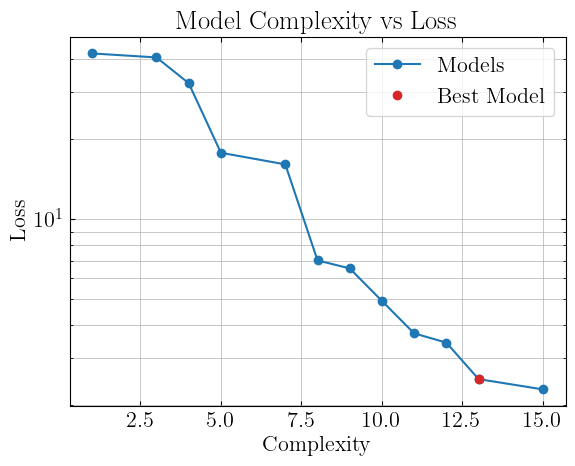

In [15]:
pareto_plot(model_R0)

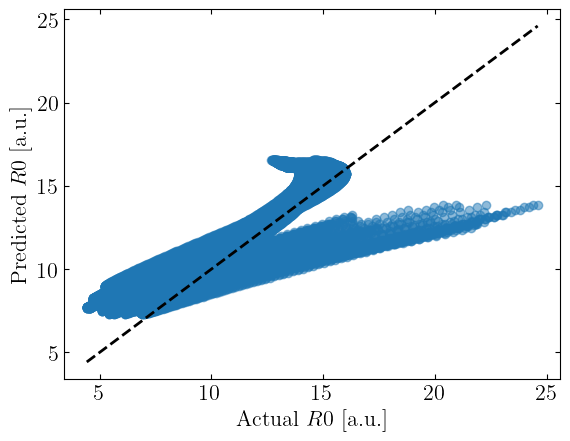

In [16]:
parity_plot('R0',model_R0)

# $R_1 = f_R(i,u,\mathrm{SOC})$

In [17]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR1_train, model = None,run_id = 'R1')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


In [18]:
df_model_R1 = model_R1.equations_

In [19]:
print_models(df_model_R1)

Model 0: Complexity=1, Loss=55.394096
Equation: 6.6941943

Model 1: Complexity=3, Loss=18.749043
Equation: 2.044681 / x2

Model 2: Complexity=4, Loss=5.5012274
Equation: log(x2) * -9.26822

Model 3: Complexity=5, Loss=2.603846
Equation: square(cube(1.7914683 - x2))

Model 4: Complexity=6, Loss=2.4775388
Equation: cube((x2 + -1.0312604) * -3.0681257)

Model 5: Complexity=7, Loss=2.3961132
Equation: exp(cube(-0.90627044 - x2) + 4.169597)

Model 6: Complexity=8, Loss=2.3306963
Equation: cube(square(1.7934813 - x2)) - cos(x0)

Model 7: Complexity=9, Loss=1.7637702
Equation: exp((0.8938147 - x2) * log(x1 + 38.12244))

Model 8: Complexity=10, Loss=1.053388
Equation: cube(sin(0.9214742 - x2) * log(x1 + 33.46219))

Model 9: Complexity=11, Loss=0.85694194
Equation: exp((0.84616965 - x2) * log((x0 * x1) + 51.36268))

Model 10: Complexity=13, Loss=0.56287915
Equation: cube(sin(0.91967356 - x2) * log(x1 + (square(x0) + 31.016167)))

Model 11: Complexity=14, Loss=0.4821486
Equation: cube(sin(0.9037

In [20]:
print_best_model(model_R1)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: -log(x0**2 + x1 + 31.016167)**3*sin(x2 - 0.91967356)**3
Loss: 0.56287915
Best model complexity: 13


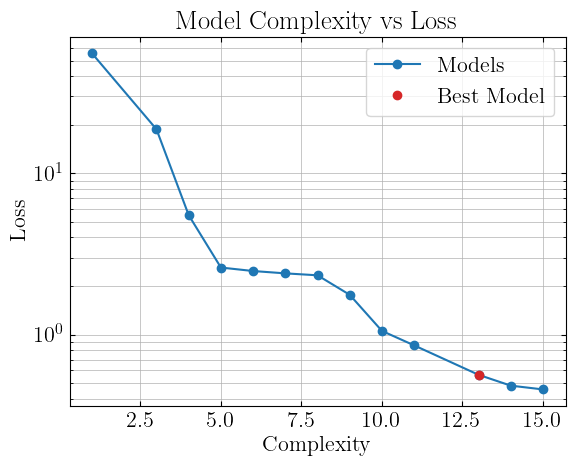

In [21]:
pareto_plot(model_R1)

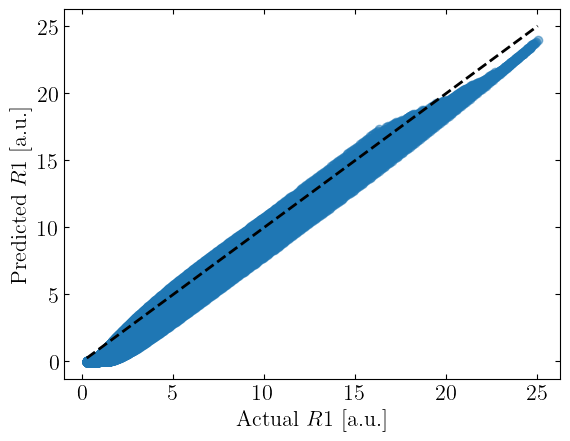

In [22]:
parity_plot('R1',model_R1)

In [23]:
#df_model_R1.to_csv('model_R1.csv', index=False)
#df_model_C1.to_csv('model_C1.csv', index=False)

# $C_1 = f_C(i,u,\mathrm{SOC})$

In [24]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = 'R1')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


In [25]:
df_model_C1 = model_C1.equations_

In [26]:
print_models(df_model_C1)

Model 0: Complexity=1, Loss=3.708729
Equation: 2.7234335

Model 1: Complexity=2, Loss=3.031682
Equation: exp(x2)

Model 2: Complexity=3, Loss=0.352508
Equation: x2 * 5.4678273

Model 3: Complexity=4, Loss=0.11107539
Equation: tan(x2) * 4.274529

Model 4: Complexity=5, Loss=0.038496718
Equation: square(sin(x2) * 3.0150068)

Model 5: Complexity=7, Loss=0.03223524
Equation: cube(cos(x2 + 4.91818)) * 7.774523

Model 6: Complexity=8, Loss=0.032215644
Equation: square(square(cos(x2 + -1.2371982)) * 2.6462522)

Model 7: Complexity=9, Loss=0.013569548
Equation: ((x1 * -0.052274488) + 9.913911) * square(sin(x2))

Model 8: Complexity=10, Loss=0.012038025
Equation: square(sin(x2)) * (cos(x1 * -0.06733371) + 8.677526)

Model 9: Complexity=11, Loss=0.0072818706
Equation: cube(cos(x2 + 4.91842)) * ((x1 * -0.044215985) + 8.459395)

Model 10: Complexity=12, Loss=0.00570713
Equation: cube(sin(x2 + 0.20583852)) * (cos(x1 * 0.060922515) + 7.2664313)

Model 11: Complexity=13, Loss=0.0055940207
Equation: c

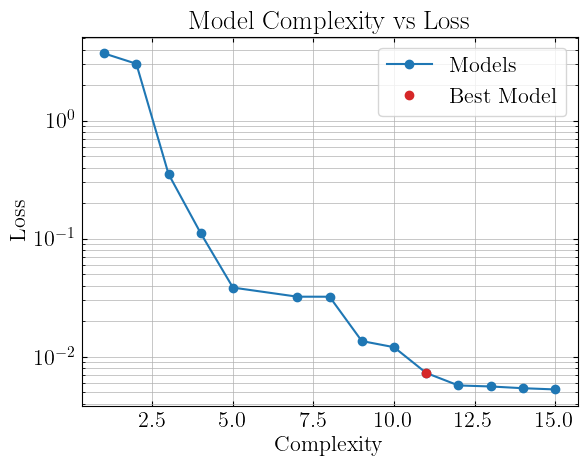

In [27]:
pareto_plot(model_C1)


In [52]:
print_best_model(model_C1)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (8.459395 + x1*(-0.044215985))*cos(x2 + 4.91842)**3
Loss: 0.0072818706
Best model complexity: 11


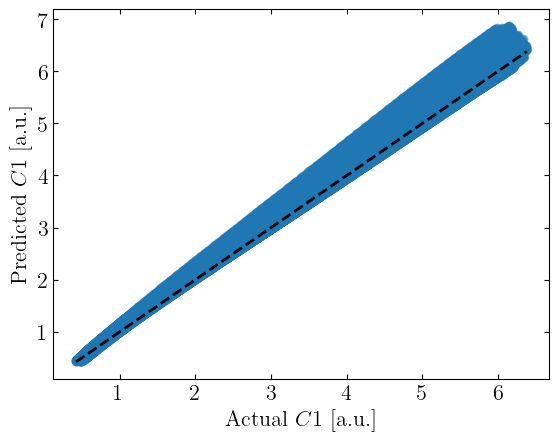

In [29]:
parity_plot('C1', model_C1)

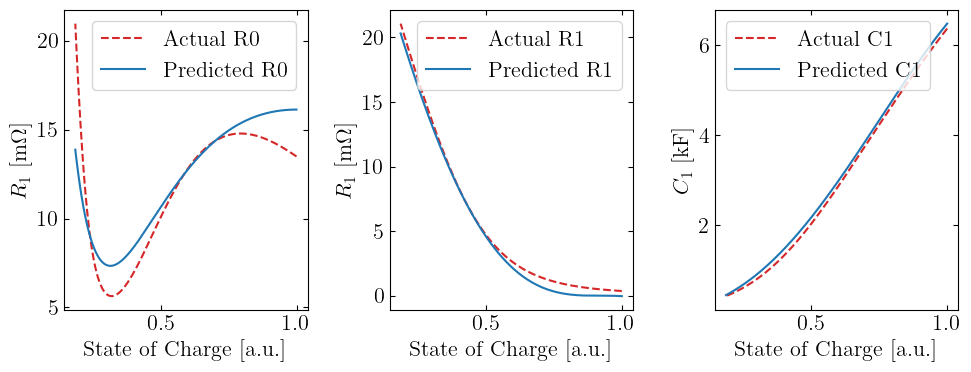

In [35]:
def plot_trajs(data = data, ind = 0, modelR = model_R1, modelC = model_C1,model_0 = model_R0, test = False):
    tr = prepare_data(data, index = ind, test=test)
    X = tr[['C', 'u_per', 'soc']].values
    YR0_pred = model_0.predict(X)
    YR1_pred = modelR.predict(X)
    YC_pred = modelC.predict(X)
    f,ax = plt.subplots(1,3, figsize=(10,4))
    ax[0].plot(tr['soc'], tr['R0'], label='Actual R0',  color=colors[1], linestyle='--')
    ax[0].plot(tr['soc'], YR0_pred, label='Predicted R0',color=colors[0])
    ax[1].plot(tr['soc'], tr['R1'], label='Actual R1',  color=colors[1], linestyle='--')
    ax[1].plot(tr['soc'], YR1_pred, label='Predicted R1',color=colors[0])
    ax[2].plot(tr['soc'], tr['C1'], label='Actual C1', color=colors[1], linestyle='--')
    ax[2].plot(tr['soc'], YC_pred, label='Predicted C1', color=colors[0])
    for a in ax:
        a.set_xlabel('State of Charge [a.u.]')
        a.legend()
    ax[0].set_ylabel(r'$R_1$ [m$\Omega$]');ax[1].set_ylabel(r'$R_1$ [m$\Omega$]') ; ax[2].set_ylabel(r'$C_1$ [kF]')

    plt.tight_layout()

plot_trajs(test = True, ind = 4)

In [37]:
SAVE  = False
if SAVE:
    save_expressions(df_model_R0, 'R0')
    save_expressions(df_model_R1, 'R1')
    save_expressions(df_model_C1, 'C1')